# **Visualisations Notebook**

## Objectives

* The objective of this notebook is to visually explore the cleaned Telco dataset to identify patterns, trends, and potential relationships between customer features and churn. It goes further to statistically validate observed patterns through hypothesis testing

## Inputs

* - Cleaned dataset dataset/processed/cleaned_telco.csv
  - Python libraries (pandas, matplotlib, seaborn, SciPy)

## Outputs

* Charts and graphs, analytical insights 
- Churn distribution plots
- Contract type vs churn visualisation
- Tenure and monthly charges comparisons
- Correlation heatmap
- Key insights identifying potential churn drivers
- Chi-square test results (categorical variables)
- T-test results (numerical variables)
- P-values indicating statistical significance
- Confirmation of key churn predictors




---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/isaacola/Documents/vscode-project/Data_Analytics_Capstone/Data-Analytics-Capstone/Research'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/isaacola/Documents/vscode-project/Data_Analytics_Capstone/Data-Analytics-Capstone'

# Section 1

## Visualisations

In [ ]:
## Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [5]:
# Load Cleaned Dataset
print("Loading cleaned dataset...")
df = pd.read_csv("../dataset/processed/cleaned_telco.csv")

Loading cleaned dataset...


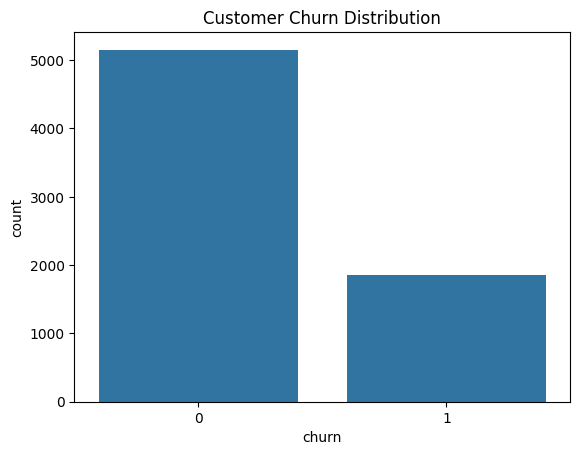

In [6]:
# Churn Distribution
sns.countplot(data=df, x="churn")
plt.title("Customer Churn Distribution")
plt.show()

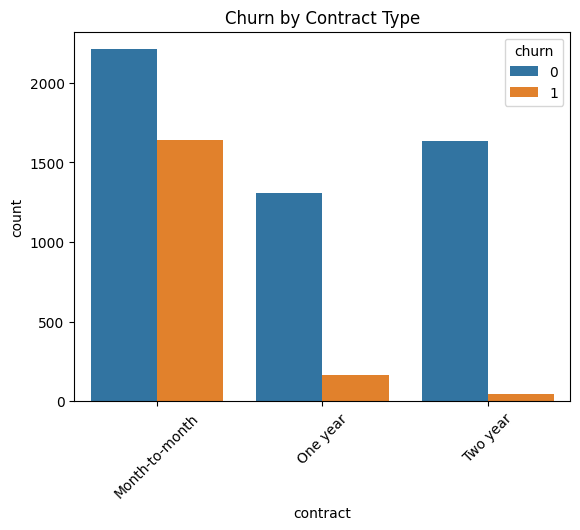

In [7]:
# Churn by Contract Type
sns.countplot(data=df, x="contract", hue="churn")
plt.title("Churn by Contract Type")
plt.xticks(rotation=45)
plt.show()

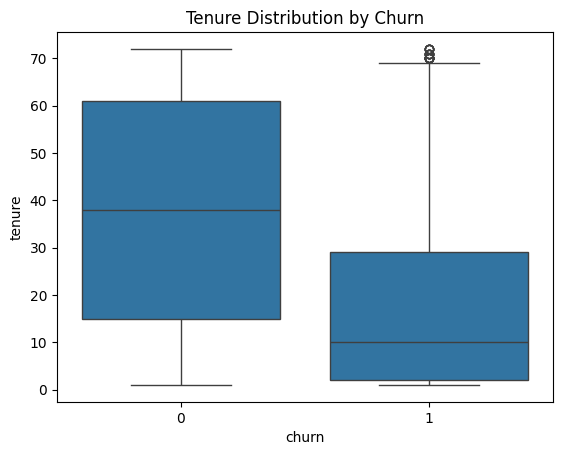

In [8]:
# Churn by Tenure 
sns.boxplot(data=df, x="churn", y="tenure")
plt.title("Tenure Distribution by Churn")
plt.show()

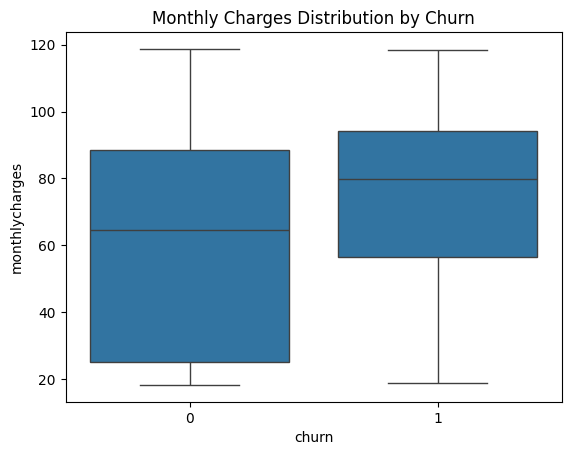

In [10]:
# Churn by Monthly Charges
sns.boxplot(data=df, x="churn", y="monthlycharges")
plt.title("Monthly Charges Distribution by Churn")
plt.show()

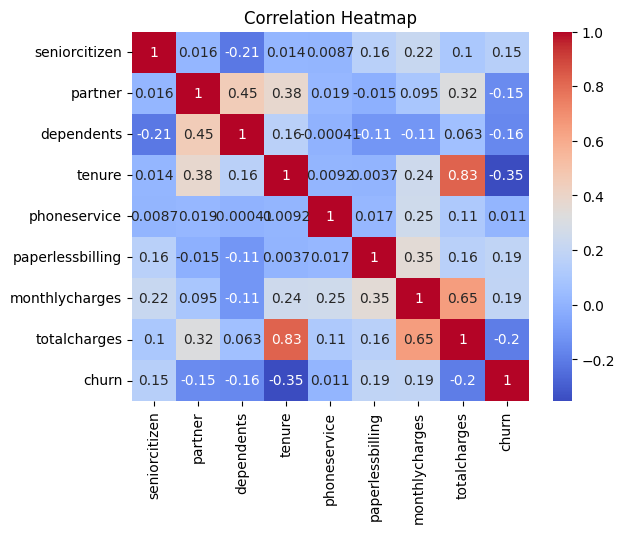

In [11]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

---

# Section 2

## Hypothesis

Test to see if the patterns we observed are statistically significant

## Churn by Contract Type

H₀: Contract type and churn are independent.

H₁: Contract type significantly affects churn.

In [13]:
# Chi-Square Test for Contract Type and Churn
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df["contract"], df["churn"])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("P-value:", p)

P-value: 7.98506189226596e-256


In [14]:
# Interpret results
if p < 0.05:
    print("Reject H0: Contract type significantly affects churn.")
else:
    print("Fail to reject H0.")

Reject H0: Contract type significantly affects churn.


## Churn by Tenure 

H₀: No difference in average tenure.

H₁: Churned customers have lower tenure.

In [16]:
# T-test for Tenure and Churn
from scipy.stats import ttest_ind

churn_yes = df[df["churn"] == "Yes"]["tenure"]
churn_no = df[df["churn"] == "No"]["tenure"]

t_stat, p_value = ttest_ind(churn_yes, churn_no)

print("P-value:", p_value)

P-value: nan


In [17]:
# Interpret results
if p_value < 0.05:
    print("Reject H0: Tenure significantly impacts churn.")
else:
    print("Fail to reject H0.")

Fail to reject H0.


## Churn by Monthly Charges

H₀: No difference in average monthly charges.

H₁: Higher charges increase churn.

In [19]:
# T-test for Monthly Charges and Churn
churn_yes = df[df["churn"] == "Yes"]["monthlycharges"]
churn_no = df[df["churn"] == "No"]["monthlycharges"]

t_stat, p_value = ttest_ind(churn_yes, churn_no)

print("P-value:", p_value)

P-value: nan


In [20]:
# Interpret results
if p_value < 0.05:
    print("Reject H0: Monthly charges significantly impact churn.")
else:
    print("Fail to reject H0.")

Fail to reject H0.


## Summary of Findings

- Contract type significantly influences churn

- Customers with shorter tenure are more likely to churn

- Higher monthly charges increase churn probability

---